# Computer Vision
## Exercise Sheet 3: Image Center, Edges, Keypoints
### Erhardt Barth / Christoph Linse / Manuel Laufer / Kathleen Anderson
Universität zu Lübeck, Institut für Neuro- und Bioinformatik

In case of questions, contact us via email: *{erhardt.barth, c.linse, m.laufer, k.anderson} @uni-luebeck.de*

## Note: Please insert the names of all participating students:

1. 
2. 
3. 
4. 
5. 


In [63]:
import sys, os
if 'google.colab' in sys.modules:
  if os.getcwd() == '/content':
    !git clone 'https://github.com/inb-luebeck/cs4250.git'
    os.chdir('cs4250')

In [64]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.morphology import dilation

%matplotlib inline

## Exercise 3.1
### Finding the Image Center
Camera calibration refers to the process of computing the intrinsic and extrinsic parameters of the camera. It is a necessary step in many computer vision applications such as 3D scene reconstruction and recognition. One important intrinsic parameter is the image center. Print out the images `ueb311.jpg` and `ueb312.jpg` and estimate the image centers by using a ruler.

**Hint**: Make small printouts of the images to have enough space around them.

In [65]:
def load_image_gray(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return image

In [66]:
def load_image_gray_normalized(image_path):
    return load_image_gray(image_path).astype('float32')/255.

In [67]:
def gradient(image):
    v = .5
    k_y = np.zeros((3, 3))
    k_y[0, 1] = -v
    k_y[2, 1] = +v

    k_x = np.zeros((3, 3))
    k_x[1, 0] = -v
    k_x[1, 2] = +v

    image = np.copy(image).astype('float32')

    gradient_x = cv2.filter2D(image, -1, k_x)
    gradient_y = cv2.filter2D(image, -1, k_y)

    return gradient_x, gradient_y


## Exercise 3.2.1
### Edge Detection
Open the image `ueb32.jpg` in Python and show the image gradients $d_x$ and $d_y$. Compute the magnitude of gradients image and apply a threshold to retain only the edges of the object. For those edges, compute and show the gradient angle image (`np.arctan2`). How can you tell the angle of the gradient from looking only at the gradients?

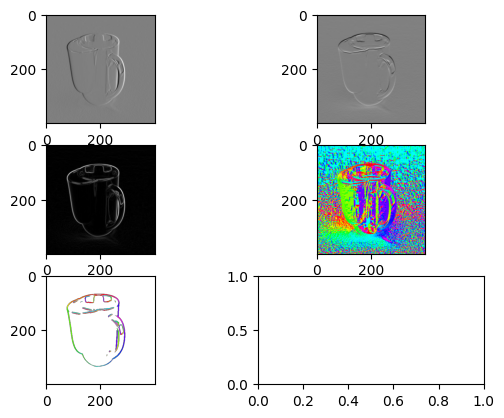

In [68]:
# load image
img = load_image_gray_normalized("./data/exercise_3/ueb32.jpg")

# smooth image
img = cv2.GaussianBlur(img, (0, 0), 1)

# compute and show gradient images
# make images comparable
gx, gy = gradient(img)
fig, axs = plt.subplots(3, 2)
vmax = max(np.abs(gx).max(), np.abs(gy).max())
axs[0, 0].imshow(gx, cmap="gray", vmin=-vmax, vmax=vmax)
axs[0, 1].imshow(gy, cmap="gray", vmin=-vmax, vmax=vmax)

# compute gradient magnitude
gm = np.sqrt(gx**2 + gy**2)
axs[1, 0].imshow(gm, cmap="gray")

# compute an angle image that should be in range [-180,+180]
angle_img = np.degrees(np.atan2(gx, gy))
axs[1, 1].imshow(angle_img, cmap="hsv", vmin=-180, vmax=180)

# show angles only for real edges
thres = 0.2 * gm.max()# 0.04
edges = np.where(gm > thres, angle_img, np.nan)
axs[2, 0].imshow(edges, cmap="hsv", vmin=-180, vmax=180)

## Exercise 3.2.2
### Canny Edge Detector
Open the image `ueb32.jpg` in Python and use the OpenCV Canny algorithm to find the edges in the image.
Compare the result with the magnitude of gradient image. Display both results side by side using `plt.subplots`.
Comment on how the two results differ and why.**Furthermore, comment how the angle image and the magnitude image are used in the Canny algorithm.**

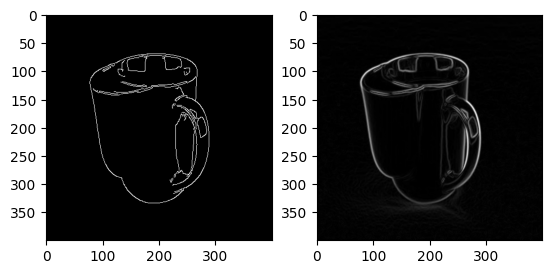

In [69]:
# load image
img_u8 = load_image_gray("./data/exercise_3/ueb32.jpg")
# compute magnitude of gradient image
# apply canny
canny = cv2.Canny(img_u8, 50, 150, L2gradient=True)
# compare results
fig, axs = plt.subplots(1, 2)
axs[0].imshow(canny, cmap="gray")
axs[1].imshow(gm, cmap="gray")

# in canny:
# orientation is quantized, then: thinning by non-maximum suppression
# gradient magnitude is used for hysteresis thresholding


## Exercise 3.3
### Key Point Detection
Implement the following key-point detectors:
* local maxima of $K$
* local maxima of $K$ − $\alpha$ $H^2$, with $\alpha$ as weighting parameter

The function is supposed to return images of the same size as the input, where the pixels contain $K$ or $K$ − $\alpha$ $H^2$.

$K$ and $H$ should be the invariants of the structure tensor $J$ (see script).
Evaluate the detectors above on two kinds of test images: (i) the synthetic image `ueb331.npy`, (ii) the
picture `ueb332.jpg`.

Comment your results with a focus on
1. the localization of the key points
2. the influence of the $H$ term as controlled via the parameter $\alpha$.

**Question**: Why do you filter the image with a Gaussian kernel a second time? It is **not** about noise removal!

**Hint**: Use the provided functions `find_local_max` and `plot_marks`.

In [70]:
def find_local_max(keypoints, thres=1e-6, k=3):
    kernel = np.ones((k, k))
    kernel[k//2, k//2] = 0
    local_max = keypoints > thres + dilation(keypoints, kernel)

    return local_max

In [71]:
def plot_marks(map, ax=None):
    if ax is None:
        _, ax = plt.subplots(1)
    col, row = np.nonzero(map)

    ax.plot(row, col, 'r.')

In [72]:
def key_points_structure(image, alpha, sigma=.1):
    # 0. filter with Gaussian kernel
    img = cv2.GaussianBlur(image, (0, 0), sigma)

    # 1. partial derivatives (Ix, Iy)
    Ix, Iy = gradient(img)

    # 2. product images
    Ixx = Ix * Ix
    Iyy = Iy * Iy
    Ixy = Ix * Iy

    # 3. filter with Gaussian kernel with sigma=1
    # this second Gaussian is the integration (averaging) step
    Jxx = cv2.GaussianBlur(Ixx, (0, 0), 1)
    Jyy = cv2.GaussianBlur(Iyy, (0, 0), 1)
    Jxy = cv2.GaussianBlur(Ixy, (0, 0), 1)

    # 4. invariants: determinant K and trace H of structure tensor J
    K = Jxx * Jyy - Jxy * Jxy
    H = Jxx + Jyy

    # return K and K_minus_H
    return K, K - alpha * (H ** 2)


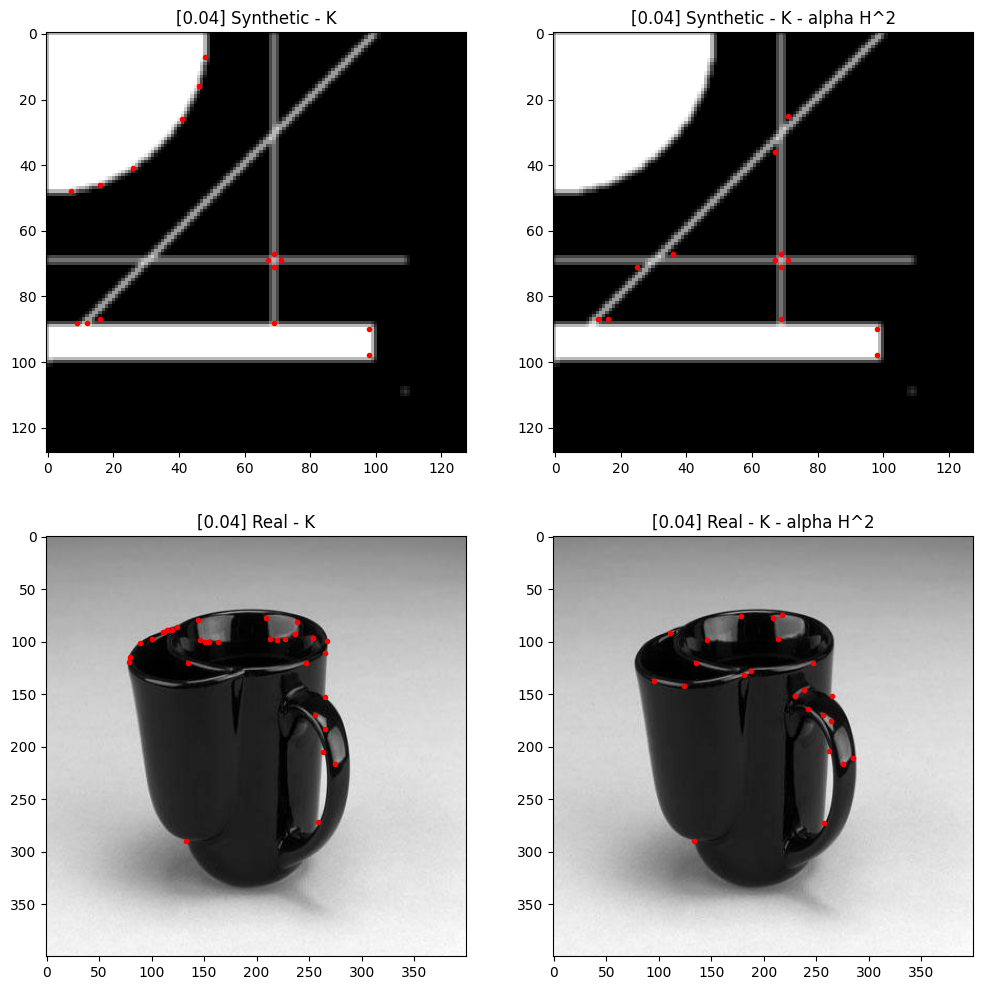

Synthetic: #K = 16  #K-alphaH = 13
Real: #K = 31  #K-alphaH = 23


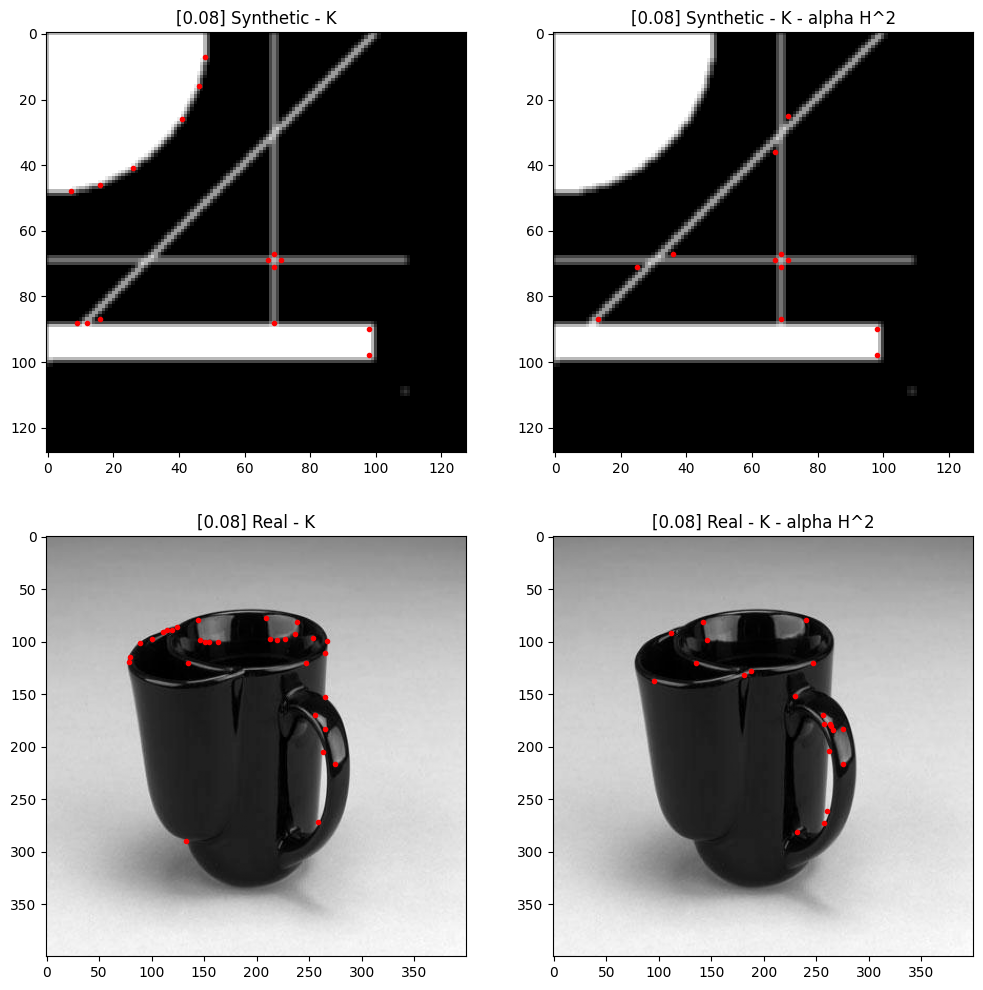

Synthetic: #K = 16  #K-alphaH = 12
Real: #K = 31  #K-alphaH = 21


In [73]:
def ex3(alpha = 0.04):
    # parameters
    # alpha = 0.04
    sigma = 1.0

    # load images
    img_synth = np.load('./data/exercise_3/ueb331.npy')
    img_real = load_image_gray_normalized('./data/exercise_3/ueb332.jpg')

    # compute responses
    K_s, R_s = key_points_structure(img_synth, alpha, sigma=sigma)
    K_r, R_r = key_points_structure(img_real, alpha, sigma=sigma)

    # thresholds for local maxima (relative)
    th_s = K_s.max() * 0.01 if K_s.max() > 0 else 1e-6
    th_rs = R_s.max() * 0.01 if R_s.max() > 0 else 1e-6
    th_r = K_r.max() * 0.01 if K_r.max() > 0 else 1e-6
    th_rr = R_r.max() * 0.01 if R_r.max() > 0 else 1e-6

    # find local maxima
    local_K_s = find_local_max(K_s, thres=th_s, k=3)
    local_R_s = find_local_max(R_s, thres=th_rs, k=3)
    local_K_r = find_local_max(K_r, thres=th_r, k=3)
    local_R_r = find_local_max(R_r, thres=th_rr, k=3)

    # plot results
    fig, axs = plt.subplots(2, 2, figsize=(12, 12))
    axs[0,0].imshow(img_synth, cmap='gray')
    axs[0,0].set_title(f'[{alpha}] Synthetic - K')
    plot_marks(local_K_s, axs[0,0])

    axs[0,1].imshow(img_synth, cmap='gray')
    axs[0,1].set_title(f'[{alpha}] Synthetic - K - alpha H^2')
    plot_marks(local_R_s, axs[0,1])

    axs[1,0].imshow(img_real, cmap='gray')
    axs[1,0].set_title(f'[{alpha}] Real - K')
    plot_marks(local_K_r, axs[1,0])

    axs[1,1].imshow(img_real, cmap='gray')
    axs[1,1].set_title(f'[{alpha}] Real - K - alpha H^2')
    plot_marks(local_R_r, axs[1,1])

    plt.show()

    print('Synthetic: #K =', local_K_s.sum(), ' #K-alphaH =', local_R_s.sum())
    print('Real: #K =', local_K_r.sum(), ' #K-alphaH =', local_R_r.sum())


ex3(0.04)
ex3(0.08)
